# 5. Обучение GNN и механизм GAT

Каждая реализация события образует графовый пример. GAT передаёт сообщения только по рёбрам, обучает коэффициенты внимания и выдаёт logits для всех возможных узлов-источников.

The notebook solves an extreme-event source-localization task on a graph:
An extreme event is observed across several connected time-series channels. Which graph node did the event start from?
This is a node-classification/ranking problem. For each complete event realization, exactly one node is treated as the true source. The GAT produces one score for every candidate node, and the node with the highest probability is the predicted source. The notebook explicitly describes each event realization as one graph example and says that the GAT outputs logits for all possible source nodes.
For 18 nodes, the output is conceptually:

P(source = node 0)
P(source = node 1)
...
P(source = node 17)
The predicted source is:
predicted_source = np.argmax(probabilities)
Why do we use multiple nodes?
A single time series can tell us that something unusual happened, but it usually cannot tell us where the event originated.
With multiple nodes, we can compare:

which node reacted first;
which node had the strongest response;
how the response weakened across the network;
whether neighboring nodes reacted consistently;
whether the observed propagation agrees with the known graph structure.
In the synthetic generator, an event begins at source_node and propagates along graph edges. Nodes farther from the source receive the event later and with lower amplitude. 
Specifically:

arrival = event_onset + 3 * distances
means that every additional graph hop introduces a delay of three time steps, while:
magnitude * np.exp(-0.22 * distances[node])
makes the event weaker with increasing distance from the source. 
This creates the information needed for source localization.

Simple example
Suppose the graph is:
Node 0 ─ Node 1 ─ Node 2 ─ Node 3
If the signals show:
Node 1: strong response at t=850
Node 0: weaker response at t=853
Node 2: weaker response at t=853
Node 3: still weaker response at t=856
then node 1 is a plausible source.
The GAT learns this kind of relationship from the node measurements and graph connections.

Why does every node need a time series?
Each node represents a measurement channel—for example:
an electrode in brain recordings;
a vibration or temperature sensor in an engine;
a financial asset or market sector;
a station in a power grid;
a device in a computer network.
The raw data is therefore:
time × nodes
The repository’s GraphTimeSeries structure explicitly defines values that way. 
In the default example:

1200 time points × 18 nodes
The time series are necessary because source localization depends partly on temporal behavior—especially the order in which nodes react.
Without a time series per node, we would lose information such as:

baseline behavior;
event onset;
response amplitude;
response duration;
response energy;
response slope;
arrival delay.
The two tasks in the complete pipeline
The project actually separates the problem into two components.
Task 1: EVT detection — when did the event occur?
The first task examines the multichannel signals and determines whether an extreme event occurred and at which time.
Conceptually:

Input:  multichannel time series
Output: detected event time
This answers:
When did the extreme event happen?
prepare_sample() first calls the EVT detector on all node signals:
detection = EVTEventDetector(baseline_end).fit_detect(series.values)
EVT is useful here because the event is represented as an unusually large tail observation relative to normal baseline behavior.

Task 2: GAT localization — where did the event originate?
After the event time is detected, the system calculates features for every node and uses the graph neural network to identify the source.
Conceptually:

Input:
    detected event
    node features
    graph connections

Output:
    probability that each node is the source
This answers:
Where did the extreme event start?
The pipeline constructs a GraphSample containing:
node features;
graph edges;
the known source label used during training.
Thus, the complete task is:

Multichannel signals
        │
        ▼
EVT detector
“When did something extreme happen?”
        │
        ▼
Node feature extraction
“How did each node respond?”
        │
        ▼
GAT
“Which node was the source?”
What information is given to the GAT?
The GAT does not directly process all 1,200 time points in this implementation. Instead, the signal around the detected event is summarized into six features for every node:
Peak — maximum standardized deviation.
Energy — average squared standardized signal.
Slope — average signal change.
Latency — how quickly the node crosses an extreme threshold.
Degree — number of graph neighbors.
Neighbor peak — average peak response of adjacent nodes.
These features are constructed in node_features(). 
The resulting GAT input has shape:

18 nodes × 6 features
For example:
Node    Peak  Energy  Slope  Latency  Degree  Neighbor peak
0       7.2    11.4    0.1     0.00      1        6.1
1       6.1     8.3    0.1     0.06      2        5.8
2       5.0     6.2    0.0     0.12      2        4.9
...
17      1.2     1.0    0.0     0.80      1        1.3
A likely source generally has an early, strong response, while surrounding nodes show delayed and attenuated responses.
Why use a GAT rather than an ordinary classifier?
An ordinary classifier could score every node independently. However, that would ignore the fact that the nodes are connected.
A Graph Attention Network uses:

Each node’s own features.
Features of connected neighboring nodes.
Learned attention weights indicating which neighbor relationships are informative.
The model contains two GATv2Conv layers. The first creates a hidden representation from each node and its neighbors; the second produces one source logit per node. 
This matters because source evidence is relational.

For example, a large peak at node 5 could be:

the true event source;
noise affecting only node 5;
a propagated event originating at adjacent node 4.
The response pattern of nodes connected to node 5 helps distinguish these cases. A GAT can learn how much attention to assign to those neighbors.
Why specifically 18 nodes?
There is no theoretical reason that the task must use exactly 18 nodes. It is the default synthetic configuration:
n_nodes: int = 18
n_groups: int = 3
With these defaults, the generator forms three structural groups of six nodes. The graph construction connects nodes within each group and connects consecutive groups. 

Eighteen is useful for the demonstration because it is:

large enough to make localization nontrivial;
small enough to display in one plot;
divisible into three equal structural groups;
computationally inexpensive.
But the same conceptual task could use:
8 sensors;
64 EEG electrodes;
100 industrial components;
hundreds of financial assets.
The number of nodes should normally correspond to the number of real measurement channels.
What is the training label?
For every generated event realization, the label is one integer:
source_node
For example:
Example 1 → source node 0
Example 2 → source node 1
Example 3 → source node 2
The model produces a logit for each node. Cross-entropy compares those logits with the known source-node index. 
Therefore, this is not:

time-series forecasting;
graph classification;
edge prediction;
detection of 18 independent events.
It is:
Node-level source classification within each event graph.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


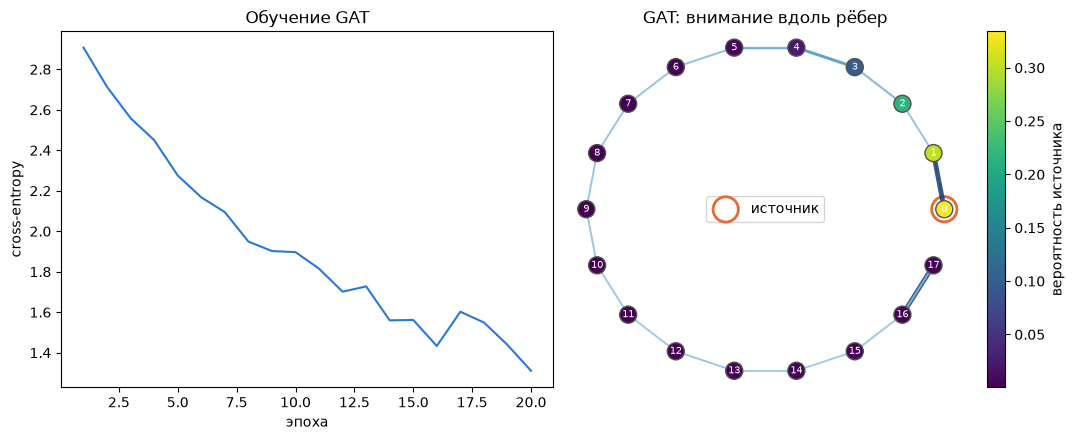

In [2]:
from evt_demo import generate_graph_time_series, train_gat_with_trace
from evt_demo.pipeline import prepare_sample
from evt_demo.visualization import plot_gat_training
samples=[prepare_sample(generate_graph_time_series(source_node=i,seed=100+i))[0] for i in range(6)]
trace=train_gat_with_trace(samples,epochs=20,seed=42)
plot_gat_training(samples[0],trace);

Слева показано обучение по cross-entropy. Справа толщина и цвет рёбер кодируют выученное внимание последнего GAT-слоя, а цвет узла — вероятность источника. Self-loop рёбра не рисуются.

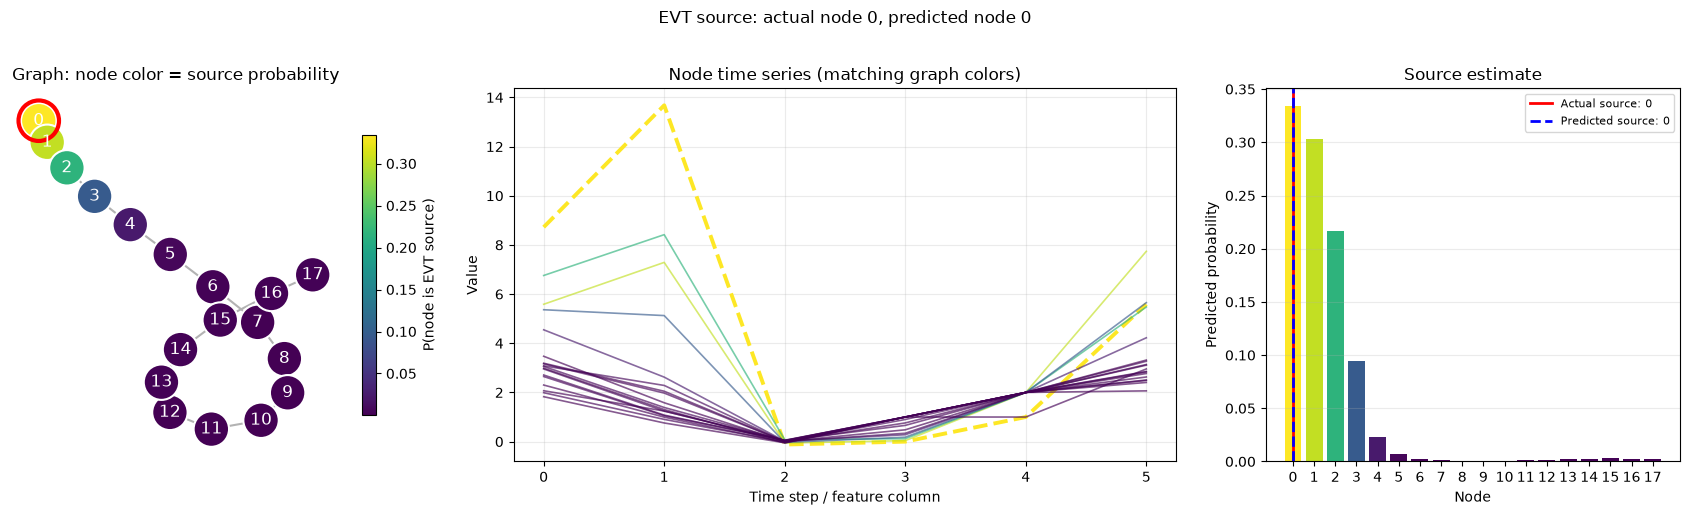

In [3]:
import numpy as np
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt

sample = samples[0]
features = np.asarray(sample.features)
if features.ndim != 2:
    raise ValueError(f"Expected a 2D node-by-time feature array, got shape {features.shape}")

n_nodes, n_steps = features.shape
actual_source = int(sample.source_node)
probabilities = np.asarray(trace.probabilities).ravel()[:n_nodes]
predicted_source = int(np.argmax(probabilities))

edge_index = np.asarray(sample.edge_index)
graph = nx.Graph()
graph.add_nodes_from(range(n_nodes))
graph.add_edges_from(
    (int(src), int(dst))
    for src, dst in edge_index.T
    if src != dst and src < n_nodes and dst < n_nodes
)
positions = nx.spring_layout(graph, seed=42)

cmap = plt.cm.viridis
norm = Normalize(vmin=float(probabilities.min()), vmax=float(probabilities.max()) + 1e-12)
fig, (ax_graph, ax_series, ax_scores) = plt.subplots(
    1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1, 1.6, 1]}
)

# Graph: node color is the model's source probability.
nx.draw_networkx_edges(graph, positions, ax=ax_graph, edge_color="0.7", width=1.5)
nx.draw_networkx_nodes(
    graph, positions, ax=ax_graph,
    node_color=probabilities, cmap=cmap, vmin=norm.vmin, vmax=norm.vmax,
    node_size=650, edgecolors="white", linewidths=1.5,
)
nx.draw_networkx_labels(graph, positions, ax=ax_graph, font_color="white")
nx.draw_networkx_nodes(
    graph, positions, nodelist=[actual_source], ax=ax_graph,
    node_size=850, node_color="none", edgecolors="red", linewidths=3,
)
if predicted_source != actual_source:
    nx.draw_networkx_nodes(
        graph, positions, nodelist=[predicted_source], ax=ax_graph,
        node_size=1050, node_color="none", edgecolors="blue",
        linewidths=2, node_shape="s",
    )
ax_graph.set_title("Graph: node color = source probability")
ax_graph.axis("off")
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax_graph, label="P(node is EVT source)", shrink=0.75,
)

# One trajectory per graph node; color matches its probability in the graph.
time = np.arange(n_steps)
for node in range(n_nodes):
    ax_series.plot(
        time, features[node],
        color=cmap(norm(probabilities[node])),
        linewidth=2.8 if node == actual_source else 1.2,
        linestyle="--" if node == predicted_source else "-",
        alpha=1.0 if node in (actual_source, predicted_source) else 0.65,
    )
ax_series.set(
    title="Node time series (matching graph colors)",
    xlabel="Time step / feature column",
    ylabel="Value",
)
ax_series.grid(alpha=0.25)

# Compare the model's node scores and mark the true source.
ax_scores.bar(np.arange(n_nodes), probabilities, color=cmap(norm(probabilities)))
ax_scores.axvline(actual_source, color="red", linewidth=2, label=f"Actual source: {actual_source}")
ax_scores.axvline(
    predicted_source, color="blue", linestyle="--", linewidth=2,
    label=f"Predicted source: {predicted_source}",
)
ax_scores.set(
    title="Source estimate",
    xlabel="Node",
    ylabel="Predicted probability",
    xticks=np.arange(n_nodes),
)
ax_scores.legend(fontsize=8)
ax_scores.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"EVT source: actual node {actual_source}, predicted node {predicted_source}",
    y=1.02,
)
plt.tight_layout()
plt.show()

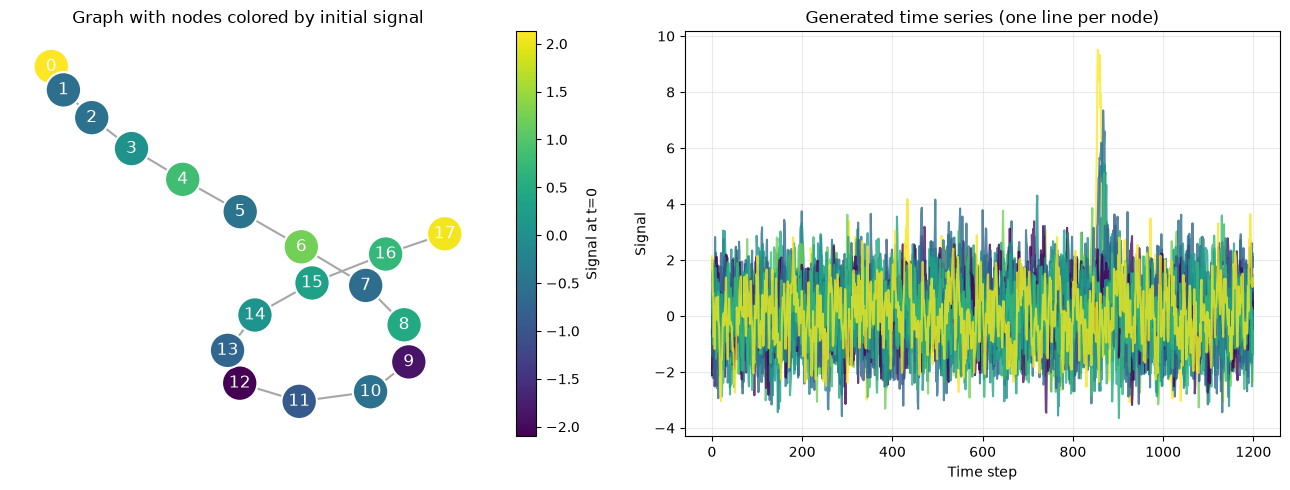

In [4]:
raw_data = generate_graph_time_series(source_node=actual_source, seed=100)

# Find a 2D array in the generator output whose dimensions include n_nodes.
def find_timeseries_arrays(obj, seen=None):
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return []
    seen.add(obj_id)

    try:
        arr = np.asarray(obj)
        if arr.ndim == 2 and n_nodes in arr.shape and arr.shape != features.shape:
            return [arr]
    except (TypeError, ValueError):
        pass

    if isinstance(obj, dict):
        children = obj.values()
    elif isinstance(obj, (list, tuple)):
        children = obj
    elif hasattr(obj, "__dict__"):
        children = vars(obj).values()
    else:
        children = ()

    found = []
    for child in children:
        found.extend(find_timeseries_arrays(child, seen))
    return found


candidates = find_timeseries_arrays(raw_data)
if not candidates:
    raise ValueError(
        "Could not find a raw 2D timeseries array in the generator output. "
        f"Inspect it with: print(type(raw_data), raw_data)"
    )

# Prefer the candidate with the most time points.
raw_series = max(candidates, key=lambda arr: max(arr.shape))
if raw_series.shape[0] == n_nodes:
    raw_series = raw_series.T  # normalize to (time, nodes)

initial_signal = raw_series[0]
signal_norm = Normalize(
    vmin=float(initial_signal.min()),
    vmax=float(initial_signal.max()) + 1e-12,
)

fig, (ax_graph, ax_signal) = plt.subplots(1, 2, figsize=(13, 5))

nx.draw_networkx_edges(graph, positions, ax=ax_graph, edge_color="0.65", width=1.5)
nx.draw_networkx_nodes(
    graph, positions, ax=ax_graph,
    node_color=initial_signal, cmap=cmap,
    vmin=signal_norm.vmin, vmax=signal_norm.vmax,
    node_size=650, edgecolors="white", linewidths=1.5,
)
nx.draw_networkx_labels(graph, positions, ax=ax_graph, font_color="white")
ax_graph.set_title("Graph with nodes colored by initial signal")
ax_graph.axis("off")
fig.colorbar(
    plt.cm.ScalarMappable(norm=signal_norm, cmap=cmap),
    ax=ax_graph, label="Signal at t=0",
)

for node_id in range(n_nodes):
    ax_signal.plot(
        np.arange(raw_series.shape[0]),
        raw_series[:, node_id],
        color=cmap(signal_norm(initial_signal[node_id])),
        alpha=0.8,
    )
ax_signal.set(
    title="Generated time series (one line per node)",
    xlabel="Time step",
    ylabel="Signal",
)
ax_signal.grid(alpha=0.25)

plt.tight_layout()
plt.show()

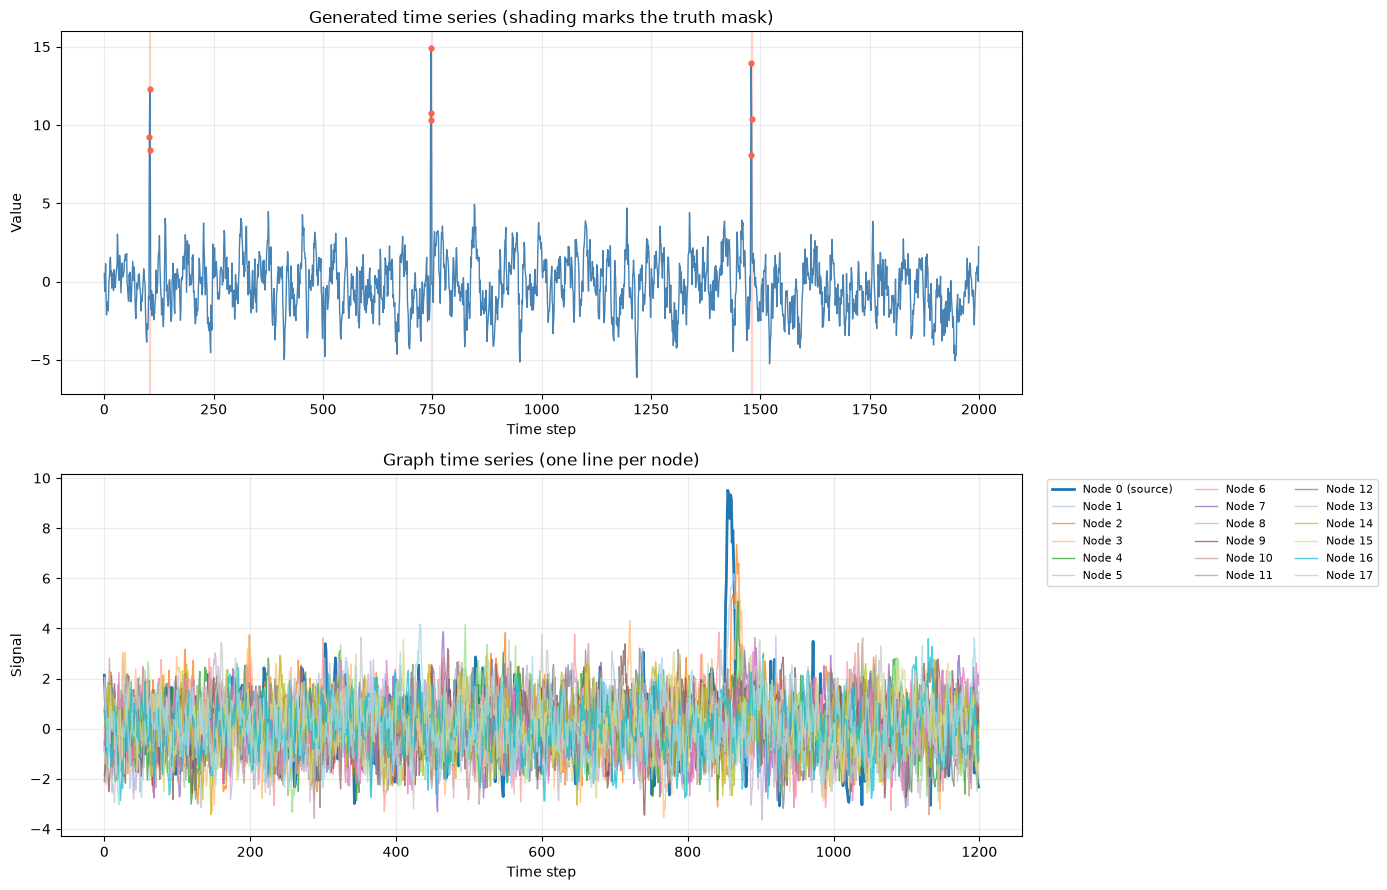

In [6]:
from evt_demo import generate_time_series_with_extreme_events
from matplotlib import colormaps

series, truth = generate_time_series_with_extreme_events(seed=42)

series = np.asarray(series).squeeze()
truth = np.asarray(truth).squeeze().astype(bool)

# Orient a 2D series so time is the first axis.
if series.ndim == 2 and series.shape[0] != truth.size and series.shape[1] == truth.size:
    series = series.T

if series.shape[0] != truth.size:
    raise ValueError(
        f"Series length ({series.shape[0]}) and truth-mask length ({truth.size}) do not match."
    )

graph_values = np.asarray(raw_data.values)  # Shape: time x nodes
if graph_values.ndim != 2:
    raise ValueError(f"Expected graph values to be 2D, got shape {graph_values.shape}")
if graph_values.shape[1] != n_nodes and graph_values.shape[0] == n_nodes:
    graph_values = graph_values.T

fig, (ax_single, ax_nodes) = plt.subplots(2, 1, figsize=(14, 9))

# Standalone series: shade contiguous intervals marked as extreme events.
t = np.arange(truth.size)
if series.ndim == 1:
    ax_single.plot(t, series, color="steelblue", linewidth=1)
else:
    for i in range(series.shape[1]):
        ax_single.plot(t, series[:, i], linewidth=1, label=f"Series {i}")
    ax_single.legend(ncol=3, fontsize=8)

event_indices = np.flatnonzero(truth)
if event_indices.size:
    starts = event_indices[np.r_[True, np.diff(event_indices) > 1]]
    ends = event_indices[np.r_[np.diff(event_indices) > 1, True]]
    for start, end in zip(starts, ends):
        ax_single.axvspan(start, end, color="tomato", alpha=0.2)
    ax_single.scatter(
        event_indices,
        series[event_indices] if series.ndim == 1 else series[event_indices, 0],
        color="tomato",
        s=12,
        label="Extreme event",
        zorder=3,
    )

ax_single.set(
    title="Generated time series (shading marks the truth mask)",
    xlabel="Time step",
    ylabel="Value",
)
ax_single.grid(alpha=0.25)

# Graph time series: each line is one node's signal over time.
try:
    node_cmap = plt.get_cmap("tab20", n_nodes)
except AttributeError:
    node_cmap = colormaps.get_cmap("tab20", n_nodes)
for node_id in range(n_nodes):
    ax_nodes.plot(
        np.arange(graph_values.shape[0]),
        graph_values[:, node_id],
        color=node_cmap(node_id),
        linewidth=2 if node_id == actual_source else 1,
        label=f"Node {node_id}" + (" (source)" if node_id == actual_source else ""),
        alpha=1 if node_id == actual_source else 0.75,
    )

ax_nodes.set(
    title="Graph time series (one line per node)",
    xlabel="Time step",
    ylabel="Signal",
)
ax_nodes.grid(alpha=0.25)
ax_nodes.legend(ncol=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Why the notebook has 18 nodes
The 18 nodes are not a requirement of GAT or EVT. They are simply the default size selected for this synthetic educational example:
def generate_graph_time_series(
    n_points=1200,
    n_nodes=18,
    n_groups=3,
    ...
)
The generator divides those 18 nodes into three structural groups—six nodes per group—and connects the nodes into a graph. This gives a graph large enough to demonstrate propagation and attention while remaining easy to visualize. You can change n_nodes; the generator only requires at least six nodes. 
For example:

generate_graph_time_series(n_nodes=10, source_node=2, seed=100)
would produce a ten-node graph. However, code that assumes 18 possible sources—particularly run_pipeline()—would also need to be generalized because it currently uses source_node=index % 18. 
Why every node has a time series
Each node represents a sensor, channel, spatial location, electrode, or other monitored entity. Consequently, every node produces a signal over time. The raw synthetic data has shape:
[time, nodes] = [1200, 18]
This representation is explicitly defined by GraphTimeSeries.values. 
The generator first creates a correlated AR(1) background signal for every node. It then injects an extreme-event pulse that:

Starts at one designated source node.
Arrives later at nodes farther from the source.
Decreases in magnitude with graph distance.
That propagation mechanism is implemented through graph distances, delayed arrival times, and distance-dependent pulse attenuation. 
Therefore, the collection of node time series allows the model to answer the intended localization question:

Given how the extreme event appeared and propagated across the graph, which node was its source?
The notebook’s final visualization consequently plots one raw trajectory for each node using graph_values[:, node_id]. 
Important distinction: the GAT does not receive all 1,200 time points directly
Although the raw example contains a time series for each node, the GAT input is not an 18 × 1200 time-series tensor.
Before training, prepare_sample() detects the event and converts each node’s temporal signal into a feature vector.  Each node receives six features:

Peak standardized response
Mean energy
Mean slope
Event latency
Graph degree
Mean neighboring-node peak
These are assembled with np.column_stack, producing an array of shape:
[nodes, features] = [18, 6]
The GAT then maps those 18 node-feature vectors through graph edges and outputs one logit per node. A softmax over those logits produces the probability that each node was the event source. 

Conceptually, the pipeline is:

Raw signals:       1200 time points × 18 nodes
                         ↓
EVT event detection and temporal summarization
                         ↓
GAT input:          18 nodes × 6 features
                         ↓
GAT output:         18 source logits/probabilities
A misleading name in the notebook
The notebook contains:
n_nodes, n_steps = features.shape
and describes features as a “node-by-time feature array.” 
That description is misleading. The second dimension is six engineered feature columns, not time steps. A more accurate version would be:

n_nodes, n_features = features.shape
Thus, one plot in the notebook that labels this axis as "Time step / feature column" is actually plotting each node’s six extracted features, not its original 1,200-point time series. The later plot using raw_data.values is the genuine node time-series plot.
One more training limitation
The notebook creates only six event realizations:
samples = [
    prepare_sample(
        generate_graph_time_series(source_node=i, seed=100+i)
    )[0]
    for i in range(6)
]
Therefore, it uses an 18-node graph but trains only on examples whose true sources are nodes 0 through 5. 

Concrete interpretation
A practical interpretation could be brain electrodes:
18 nodes              = 18 electrodes
Time series per node  = voltage measured at each electrode
Extreme event         = seizure-like activity
EVT detector          = determines when abnormal activity begins
GAT                    = estimates which electrode/location initiated it
Graph edges            = anatomical or functional connections
Another example could be an engine:
18 nodes              = 18 sensors/components
Time series per node  = temperature or vibration
Extreme event         = an abnormal spike
EVT detector          = detects the abnormal operating moment
GAT                    = identifies the component where the fault began
Graph edges            = physical/component dependencies
Short answer
We use 18 nodes with a time series at every node because the task is:
Detect an extreme event in a multichannel system and localize the graph node where it originated.
The time series tell us how every node behaves over time. EVT tells us when the abnormal event happened. The GAT combines per-node response features with graph connectivity to predict where it started. The value 18 is only a convenient synthetic default; it is not required by the method.|